In [1]:
import sys
sys.path.insert(0, '/Users/aayushjoshi/MyFiles/CS/487/double-descent/hessian-eff-dim')

import math
import torch
import hess
import matplotlib.pyplot as plt
from hess.nets import SimpleNet
import hess.loss_surfaces as loss_surfaces
import numpy as np
import sklearn.datasets as datasets
from sklearn.datasets import make_moons
import hess.utils as utils

In [2]:
def twospirals(n_points, noise=.5, random_state=920):
    """
     Returns the two spirals dataset.
    """
    n = np.sqrt(np.random.rand(n_points,1)) * 600 * (2*np.pi)/360
    d1x = -1.5*np.cos(n)*n + np.random.randn(n_points,1) * noise
    d1y =  1.5*np.sin(n)*n + np.random.randn(n_points,1) * noise
    return (np.vstack((np.hstack((d1x,d1y)),np.hstack((-d1x,-d1y)))),
            np.hstack((np.zeros(n_points),np.ones(n_points))))

def makemoons(n_points, noise=.5, random_state=920):
    """
     Returns the make moons dataset.
    """
    return make_moons(n_samples=n_points, noise=noise, random_state=random_state)

In [3]:
np.random.permutation(10)

array([6, 9, 5, 8, 2, 3, 7, 1, 4, 0])

In [4]:
X, Y = make_moons(1500, noise=0.2)
perm = np.random.permutation(1500)
X = X[perm,:]
Y = Y[perm]
num_test = 1000

In [5]:
X.shape

(1500, 2)

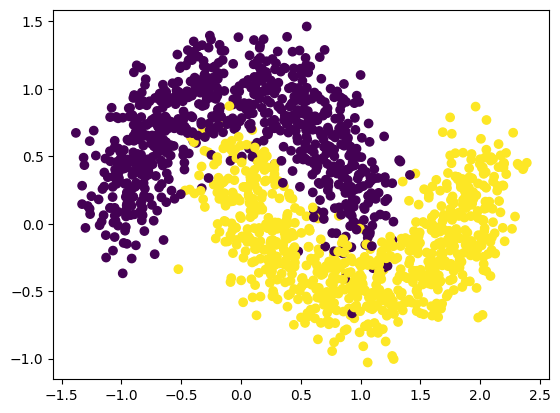

In [6]:
plt.scatter(X[:,0], X[:,1], c=Y)

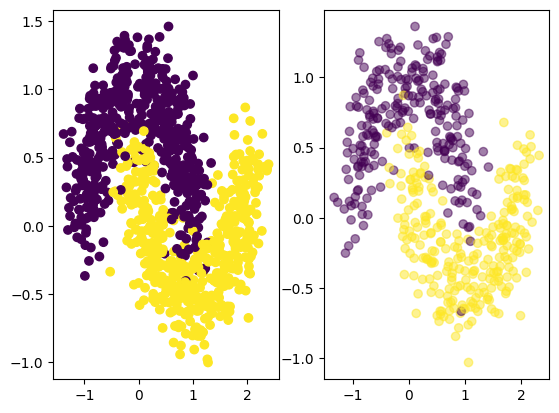

In [7]:
fig, ax = plt.subplots(1, 2)
ax[0].scatter(X[:num_test, 0], X[:num_test, 1], c=Y[:num_test])
ax[1].scatter(X[num_test:,0], X[num_test:, 1], c=Y[num_test:], alpha = 0.5)

In [8]:
train_x = torch.FloatTensor(X[:num_test])
test_x = torch.FloatTensor(X[num_test:])

train_y = torch.FloatTensor(Y[:num_test]).unsqueeze(-1)
test_y = torch.FloatTensor(Y[num_test:]).unsqueeze(-1)

In [9]:
use_cuda = torch.cuda.is_available()
if use_cuda:
    torch.cuda.set_device(0)
    torch.set_default_tensor_type(torch.cuda.FloatTensor)
    train_x, train_y = train_x.cuda(), train_y.cuda()
    test_x, test_y = test_x.cuda(), test_y.cuda()

In [10]:
def train_model(model, train_x, train_y):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_func = torch.nn.BCEWithLogitsLoss()

    losses = []
    trainL = -1

    for step in range(2000):
        optimizer.zero_grad()
        outputs = model(train_x)

        loss=loss_func(outputs, train_y)
        trainL = loss.detach().item()
        # if step % 500 is 0:
        #     print("train loss = ", trainL)
        losses.append(trainL)
        loss.backward()
        optimizer.step()    
    print("train loss = ", trainL)
    return losses

In [11]:
def get_model(hidden_size=20, n_hidden=5):
    in_dim = 2
    out_dim = 1
    model = hess.nets.SimpleNet(in_dim, out_dim, n_hidden=n_hidden, hidden_size=hidden_size,
                         activation=torch.nn.ELU(), bias=True)
    
    if use_cuda:
        model=model.cuda()
        
    return model

In [12]:
import hess.utils as utils

def get_hessian(model, train_x, train_y):
    n_par = sum(torch.numel(p) for p in model.parameters())

    hessian = torch.zeros(n_par, n_par)
    for pp in range(n_par):
        base_vec = torch.zeros(n_par).unsqueeze(0)
        base_vec[0, pp] = 1.

        base_vec = utils.unflatten_like(base_vec, model.parameters())
        utils.eval_hess_vec_prod(base_vec, list(model.parameters()), model,
                                criterion=torch.nn.BCEWithLogitsLoss(),
                                inputs=train_x, targets=train_y)
        if pp == 0:
            output = utils.gradtensor_to_tensor(model, include_bn=True)
            hessian = torch.zeros(output.nelement(), output.nelement())
            hessian[:, pp] = output

        hessian[:, pp] = utils.gradtensor_to_tensor(model, include_bn=True).cpu()
        
    return hessian

In [ ]:
# Calculate parameters
i_values = [0, 1, 2, 3, 4, 5, 6, 11, 12, 13]

for i in i_values:
    model = get_model(n_hidden = i)
    print(f"{i}: {sum(p.numel() for p in model.parameters())}")

1: 501
2: 921
3: 1341
4: 1761
5: 2181
6: 2601
11: 4701
12: 5121
13: 5541


In [ ]:
rep_full_list = []

# for rep in range(25):
for rep in range(5):
    print(f"rep: {rep}")
    eigs_list = []
    losses_list = []
    num_pars = []
    #hessian_list = []
    test_loss_list = []
    
    # for i in range(1, 15):
    for i in i_values:
        print(f'now running model depth: {i}')

        model = get_model(n_hidden = i)
        n_par = sum(p.numel() for p in model.parameters())

        losses = train_model(model, train_x, train_y)

        hessian = get_hessian(model, train_x, train_y).detach()
        
        with torch.no_grad():
            test_loss = torch.nn.BCEWithLogitsLoss()(model(test_x), test_y)
            print('test loss:', test_loss.item())
        
        losses_list.append(losses)
        eigs_list.append(np.linalg.eig(hessian.cpu().numpy())[0])
        num_pars.append(n_par)
        #hessian_list.append(hessian)
        test_loss_list.append(test_loss.item())
        del hessian, model
        
    rep_full_list.append([losses_list, eigs_list, test_loss_list])

In [16]:
def eff_dim(x, s = 0.1):
    return np.sum(x / (x + s))

In [17]:
ed_list = []
fl_list = []
for losses_list, eigs_list, _ in rep_full_list:
    eff_dim_arr = np.array([eff_dim(ee, s = 50.) for ee in eigs_list])
    final_loss = [l[-1] for l in losses_list]

    ed_list.append(eff_dim_arr)
    fl_list.append(final_loss)
    
ed_list = np.array(ed_list)
fl_list = np.array(fl_list)
tl_list = np.array([ee[-1] for ee in rep_full_list])

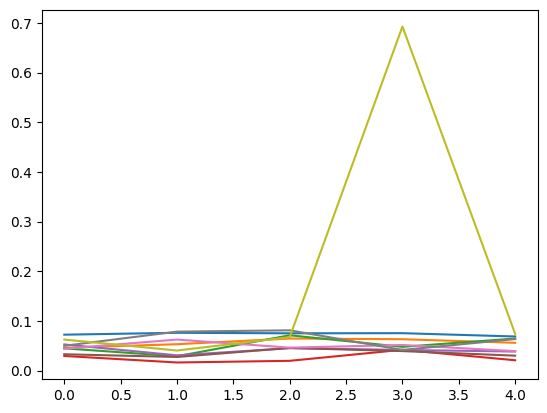

In [18]:
plt.plot(fl_list)

Text(0.5, 0.98, 'Increasing Depth')

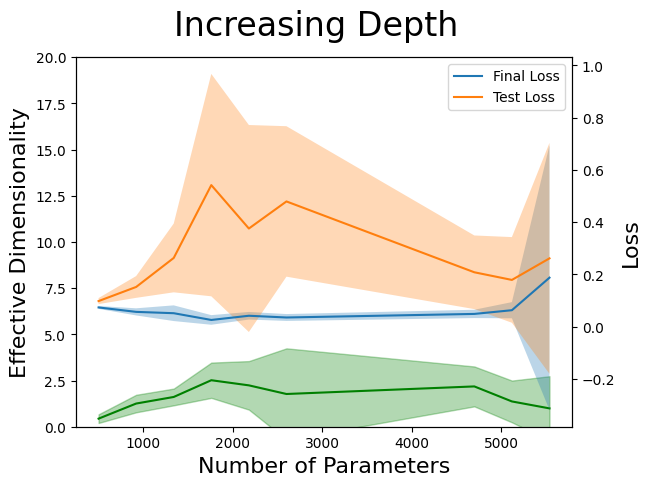

In [20]:
fig, ax = plt.subplots()

ax.plot(num_pars, ed_list.mean(0), label = 'Effective Dim', color = 'green')
ax.fill_between(num_pars, ed_list.mean(0) - 2 * ed_list.std(0), ed_list.mean(0) + 2*ed_list.std(0), alpha = 0.3,
               color='green')
ax.set_ylabel('Effective Dimensionality', fontsize = 16)
ax.set_ylim((0, 20))

ax2 = ax.twinx()
ax2.plot(num_pars, fl_list.mean(0), label = 'Final Loss')
ax2.fill_between(num_pars, fl_list.mean(0) - 2 * fl_list.std(0), fl_list.mean(0) + 2*fl_list.std(0), alpha = 0.3)

ax2.plot(num_pars, tl_list.mean(0), label = 'Test Loss')
ax2.fill_between(num_pars, tl_list.mean(0) - 2 * tl_list.std(0), tl_list.mean(0) + 2*tl_list.std(0), alpha = 0.3)
ax2.set_ylabel('Loss', fontsize = 16)
ax2.legend()

ax.set_xlabel('Number of Parameters', fontsize = 16)
fig.suptitle('Increasing Depth', fontsize = 24)
#plt.semilogy()
#plt.ylim(0, 3)
#plt.vlines(train_x.shape[0], 0, 3)

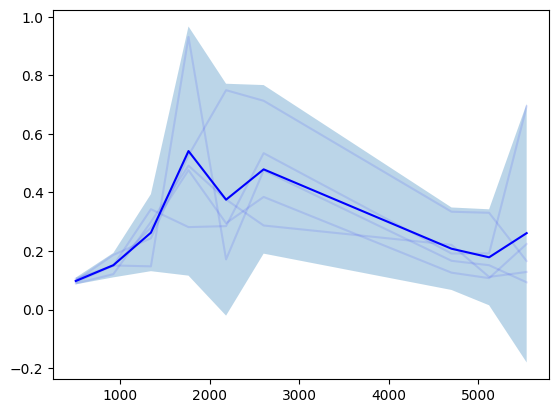

In [21]:
plt.plot(num_pars, tl_list.mean(0), label = 'Test Loss', color= 'blue')
plt.fill_between(num_pars, tl_list.mean(0) - 2 * tl_list.std(0), tl_list.mean(0) + 2*tl_list.std(0), alpha = 0.3)

plt.plot(num_pars, tl_list.T, color = 'blue', alpha = 0.1)

(0.0, 16.0)

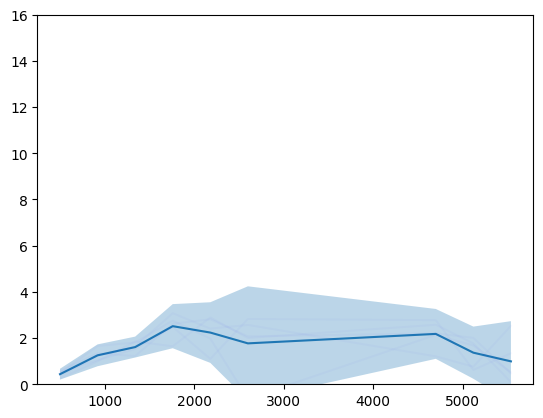

In [22]:
plt.plot(num_pars, ed_list.mean(0), label = 'Effective Dim')
plt.fill_between(num_pars, ed_list.mean(0) - 2 * ed_list.std(0), ed_list.mean(0) + 2*ed_list.std(0), alpha = 0.3)

plt.plot(num_pars, ed_list.T, color = 'blue', alpha = 0.02)
plt.ylim((0, 16))

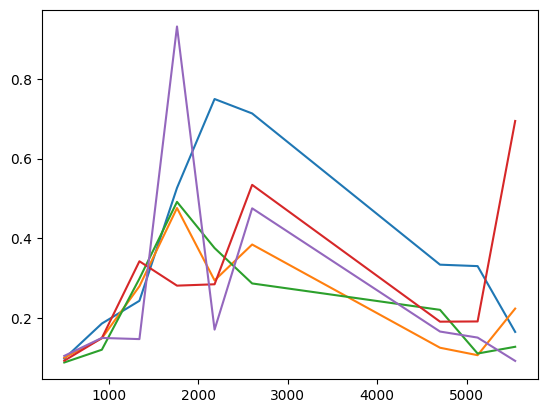

In [23]:
plt.plot(num_pars, tl_list.T)

In [24]:
import pickle

with open('../moons_depth_1_13.pkl', 'wb') as handle:
    pickle.dump([rep_full_list, num_pars], handle, pickle.HIGHEST_PROTOCOL)

In [ ]:
rep_full_list